<a href="https://colab.research.google.com/github/ahmed8809/FlyRank_intern/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Structured Content Performance Archetypes

## Research Question

**What performance archetypes exist across the content inventory?**

This case study starts from a practical FlyRank content problem: analysts need to
triage large content inventories and decide which pages deserve human review first,
without treating staleness alone as proof that a refresh will help. The paper tests
whether structured search-performance and freshness signals can reveal recurring
groups of content items with similar observed behavior.

The goal is to provide an interpretable performance lens and a human-reviewed
prioritization framework, not to claim semantic content types or causal refresh effects.


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import duckdb

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    f"CREATE SECRET (TYPE huggingface, TOKEN {HF_TOKEN})"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

SNAPSHOT_MONTH = "2026-03"

print("Warehouse connection ready.")

Warehouse connection ready.


## 1. Question

### Research question

**What performance archetypes exist across the content inventory?**

The analysis treats each client-content pair as an observation and uses
structured March 2026 search-performance and freshness metrics to discover
recurring performance patterns.

### Decision supported

The resulting archetypes are intended to help SEO/content analysts:

- understand broad performance patterns;
- identify unusually stale or low-visibility groups;
- prioritize pages for human review;
- distinguish descriptive performance patterns from operational rules.

This is an **unsupervised clustering problem**. There is no ground-truth
prediction label.

## 2. Data

The analysis uses the **FlyRank internship warehouse release**.

The overall warehouse contains approximately 79 million daily production
search-performance records. This paper uses a restricted **March 2026
snapshot** rather than the entire warehouse.

### Tables used

- `fact_content_daily_performance`
- `dim_content`

The fact table contains daily performance observations for each
`client_hash_id × content_hash_id × report_date`.

The content dimension provides the content update date used to derive
`stale_days`.

### Public-safety restrictions

The analysis does not use or publish:

- client names;
- raw URLs;
- article titles;
- private search queries;
- proprietary text;
- private business information.

Hashed identifiers are retained internally only for grouping and validation.

In [ ]:
march_features = con.sql(f"""
WITH march AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        SUM(COALESCE(f.gsc_impressions, 0)) AS gsc_impressions,
        SUM(COALESCE(f.gsc_clicks, 0)) AS gsc_clicks,

        AVG(f.gsc_avg_position) AS gsc_avg_position,

        MAX(f.report_date) AS snapshot_date,

        MAX(
            CASE
                WHEN f.gsc_avg_position IS NULL THEN 1
                ELSE 0
            END
        ) AS position_missing

    FROM read_parquet(
        '{REL}/fact_content_daily_performance/month=2026-03/*.parquet'
    ) f

    WHERE f.gsc_data_available IS TRUE

    GROUP BY
        f.client_hash_id,
        f.content_hash_id
),

content AS (
    SELECT
        client_hash_id,
        content_hash_id,
        content_updated_date
    FROM read_parquet(
        '{REL}/dim_content.parquet'
    )
)

SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.gsc_impressions,
    m.gsc_clicks,

    CASE
        WHEN m.gsc_impressions > 0
        THEN m.gsc_clicks::DOUBLE / m.gsc_impressions
        ELSE 0
    END AS gsc_ctr,

    m.gsc_avg_position,
    m.position_missing,

    DATE_DIFF(
        'day',
        c.content_updated_date,
        m.snapshot_date
    ) AS stale_days

FROM march m

INNER JOIN content c
    ON m.client_hash_id = c.client_hash_id
    AND m.content_hash_id = c.content_hash_id

WHERE
    c.content_updated_date IS NOT NULL
    AND c.content_updated_date <= m.snapshot_date
""").df()

print("Rows:", len(march_features))
print("Clients:", march_features["client_hash_id"].nunique())
display(march_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 27886
Clients: 33


,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,position_missing,stale_days
0,client_73cda7b4e4f265ea,content_0ae27a6ddd60eeb5,239.0,0.0,0.000000,7.816447,0,34
1,client_73cda7b4e4f265ea,content_3acdcf1b7d0dc0a2,53.0,0.0,0.000000,8.989130,0,34
2,client_73cda7b4e4f265ea,content_abf1a950d7195e80,31.0,0.0,0.000000,13.203704,0,34
3,client_73cda7b4e4f265ea,content_17a95a8b50af688a,146.0,0.0,0.000000,11.098505,0,34
4,client_73cda7b4e4f265ea,content_77acbbeb2f9efa82,1792.0,6.0,0.003348,3.817908,0,34


In [ ]:
print("Shape:", march_features.shape)

print("\nMissing values:")
display(
    march_features[
        [
            "gsc_impressions",
            "gsc_clicks",
            "gsc_ctr",
            "gsc_avg_position",
            "stale_days",
            "position_missing"
        ]
    ].isna().sum()
)

print("\nNegative stale days:")
print(
    (march_features["stale_days"] < 0).sum()
)

print("\nNumber of clients:")
print(
    march_features["client_hash_id"].nunique()
)

Shape: (27886, 8)

Missing values:


,0
gsc_impressions,0
gsc_clicks,0
gsc_ctr,0
gsc_avg_position,0
stale_days,0
position_missing,0



Negative stale days:
0

Number of clients:
33


## 3. Methodology

### Model

The primary model is **K-Means clustering**.

K-Means was selected because the objective is to discover recurring groups
of observations rather than predict a known target.

### Features

The candidate structured features are:

- March GSC impressions;
- March GSC clicks;
- GSC click-through rate;
- average search position;
- content staleness in days.

`client_hash_id` and `content_hash_id` are never used as model features.

Impressions and clicks are transformed using `log1p` because their
distributions are strongly right-skewed.

All clustering features are standardized using parameters fitted only on
the training clients.

### Validation

A client-grouped split is used so that pages belonging to the same client
cannot appear in both training and validation.

This is preferable to a random page-level split because pages from the same
client may share systematic characteristics.

### Leakage controls

The analysis uses only the March 2026 snapshot.

No future performance outcome is used.

K-Means has no prediction label, so traditional target leakage does not apply.

The validation model is fitted only on training clients and then applied to
held-out clients.

In [ ]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, valid_idx = next(
    splitter.split(
        march_features,
        groups=march_features["client_hash_id"]
    )
)

train_df = march_features.iloc[train_idx].copy()
valid_df = march_features.iloc[valid_idx].copy()

print("Training rows:", len(train_df))
print("Validation rows:", len(valid_df))

print("\nTraining clients:", train_df["client_hash_id"].nunique())
print("Validation clients:", valid_df["client_hash_id"].nunique())

overlap = (
    set(train_df["client_hash_id"])
    &
    set(valid_df["client_hash_id"])
)

print("\nClient overlap:", len(overlap))

Training rows: 15198
Validation rows: 12688

Training clients: 26
Validation clients: 7

Client overlap: 0


In [ ]:
CLUSTER_FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_ctr",
    "gsc_avg_position",
    "stale_days",
]


def make_cluster_matrix(df):
    X = df[CLUSTER_FEATURES].copy()

    X["gsc_impressions"] = np.log1p(
        X["gsc_impressions"]
    )

    X["gsc_clicks"] = np.log1p(
        X["gsc_clicks"]
    )

    return X


X_train_raw = make_cluster_matrix(train_df)
X_valid_raw = make_cluster_matrix(valid_df)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

print("Training matrix:", X_train.shape)
print("Validation matrix:", X_valid.shape)

Training matrix: (15198, 5)
Validation matrix: (12688, 5)


In [ ]:
k_results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_train)

    score = silhouette_score(
        X_train,
        labels
    )

    k_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": score
    })

k_results_df = pd.DataFrame(k_results)

display(
    k_results_df.round(4)
)

,k,inertia,silhouette
0,2,59249.4658,0.5114
1,3,44929.5486,0.3795
2,4,33731.9849,0.3881
3,5,25435.1423,0.4174
4,6,21058.5747,0.3472


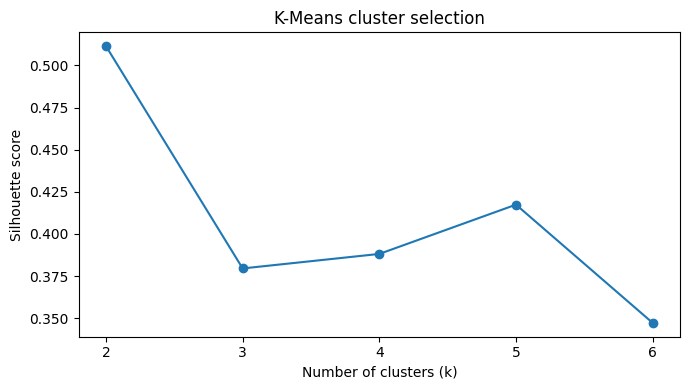

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(
    k_results_df["k"],
    k_results_df["silhouette"],
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means cluster selection")

plt.xticks(
    k_results_df["k"]
)

plt.tight_layout()
plt.show()

In [ ]:
FINAL_K = 2

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

train_clusters = kmeans.fit_predict(X_train)

valid_clusters = kmeans.predict(X_valid)

train_clustered = train_df.copy()
valid_clustered = valid_df.copy()

train_clustered["cluster"] = train_clusters
valid_clustered["cluster"] = valid_clusters

training_silhouette = silhouette_score(
    X_train,
    train_clusters
)

validation_silhouette = silhouette_score(
    X_valid,
    valid_clusters
)

print(
    f"Training silhouette: {training_silhouette:.4f}"
)

print(
    f"Validation silhouette: {validation_silhouette:.4f}"
)

Training silhouette: 0.5114
Validation silhouette: 0.6875


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
profile = (
    train_clustered
    .groupby("cluster")
    .agg(
        n=("content_hash_id", "count"),

        impressions_mean=("gsc_impressions", "mean"),
        impressions_median=("gsc_impressions", "median"),

        clicks_mean=("gsc_clicks", "mean"),
        clicks_median=("gsc_clicks", "median"),

        ctr_mean=("gsc_ctr", "mean"),
        ctr_median=("gsc_ctr", "median"),

        position_mean=("gsc_avg_position", "mean"),
        position_median=("gsc_avg_position", "median"),

        stale_days_mean=("stale_days", "mean"),
        stale_days_median=("stale_days", "median")
    )
)

print("Training profiles:")
display(profile.round(3))

Training profiles:


,n,impressions_mean,impressions_median,clicks_mean,clicks_median,ctr_mean,ctr_median,position_mean,position_median,stale_days_mean,stale_days_median
cluster,,,,,,,,,,,
0,13636,1257.320,319.0,2.186,0.0,0.002,0.0,16.793,10.864,32.921,34.0
1,1562,45.361,3.0,0.168,0.0,0.020,0.0,12.314,6.000,134.280,130.0


In [ ]:
valid_profile = (
    valid_clustered
    .groupby("cluster")
    .agg(
        n=("content_hash_id", "count"),

        impressions_mean=("gsc_impressions", "mean"),
        impressions_median=("gsc_impressions", "median"),

        clicks_mean=("gsc_clicks", "mean"),
        clicks_median=("gsc_clicks", "median"),

        ctr_mean=("gsc_ctr", "mean"),
        ctr_median=("gsc_ctr", "median"),

        position_mean=("gsc_avg_position", "mean"),
        position_median=("gsc_avg_position", "median"),

        stale_days_mean=("stale_days", "mean"),
        stale_days_median=("stale_days", "median")
    )
)

print("Validation profiles:")
display(valid_profile.round(3))

Validation profiles:


,n,impressions_mean,impressions_median,clicks_mean,clicks_median,ctr_mean,ctr_median,position_mean,position_median,stale_days_mean,stale_days_median
cluster,,,,,,,,,,,
0,12607,1371.038,319.0,3.817,0.0,0.002,0.0,13.200,7.333,31.536,34.0
1,81,11.556,4.0,0.049,0.0,0.041,0.0,18.259,7.583,208.901,230.0


In [19]:
# Robust archetype naming based on the learned training-cluster profiles.
# Cluster IDs themselves are arbitrary, so names are assigned from the
# training profile rather than from numeric cluster labels.

train_profile_for_naming = (
    train_clustered
    .groupby("cluster")
    .agg(
        impressions_median=("gsc_impressions", "median"),
        stale_days_median=("stale_days", "median"),
        impressions_mean=("gsc_impressions", "mean"),
        stale_days_mean=("stale_days", "mean")
    )
)

# Stale Low-Demand:
# relatively lower visibility + higher staleness.
stale_cluster = (
    train_profile_for_naming
    .sort_values(
        ["stale_days_median", "impressions_median"],
        ascending=[False, True]
    )
    .index[0]
)

remaining_clusters = [
    c for c in train_profile_for_naming.index
    if c != stale_cluster
]

established_cluster = remaining_clusters[0]

ARCHETYPE_NAMES = {
    stale_cluster: "Stale Low-Demand",
    established_cluster: "Visible / Established"
}

train_clustered["archetype"] = (
    train_clustered["cluster"].map(ARCHETYPE_NAMES)
)

valid_clustered["archetype"] = (
    valid_clustered["cluster"].map(ARCHETYPE_NAMES)
)

print("Archetype mapping:")
print(ARCHETYPE_NAMES)

print("\nTraining distribution:")
display(
    train_clustered["archetype"]
    .value_counts()
    .to_frame("pages")
)

print("\nValidation distribution:")
display(
    valid_clustered["archetype"]
    .value_counts()
    .to_frame("pages")
)

Archetype mapping:
{np.int32(1): 'Stale Low-Demand', 0: 'Visible / Established'}

Training distribution:


,pages
archetype,
Visible / Established,13636
Stale Low-Demand,1562



Validation distribution:


,pages
archetype,
Visible / Established,12607
Stale Low-Demand,81


In [ ]:
# Put the model archetype and the Week-4 baseline on the same held-out rows.
# This is an operational comparison, not predictive accuracy: the clustering is
# unsupervised and has no ground-truth outcome label.

valid_comparison = valid_clustered[
    ["client_hash_id", "content_hash_id", "archetype",
     "gsc_impressions", "stale_days"]
].copy()

valid_comparison["model_stale_low_demand"] = (
    valid_comparison["archetype"].eq("Stale Low-Demand")
)

valid_comparison["baseline_refresh"] = (
    (valid_comparison["stale_days"] >= 90)
    & (valid_comparison["gsc_impressions"] >= 1000)
)

valid_comparison["baseline_action"] = np.where(
    valid_comparison["baseline_refresh"],
    "refresh",
    "monitor"
)

model_count = int(valid_comparison["model_stale_low_demand"].sum())
baseline_count = int(valid_comparison["baseline_refresh"].sum())
overlap_count = int(
    (
        valid_comparison["model_stale_low_demand"]
        & valid_comparison["baseline_refresh"]
    ).sum()
)

comparison_summary = pd.DataFrame({
    "framework": [
        "K-Means: Stale Low-Demand",
        "Week-4 baseline: Refresh"
    ],
    "validation_items": [model_count, baseline_count],
    "validation_share_pct": [
        100 * model_count / len(valid_comparison),
        100 * baseline_count / len(valid_comparison)
    ]
})

print("Held-out operational comparison:")
display(comparison_summary.round(3))

print(
    f"Overlap between model stale/low-demand and baseline refresh: "
    f"{overlap_count} items"
)


## Model vs baseline

The Week-4 baseline and K-Means are evaluated on the **same held-out validation
rows**, but they answer different questions.

The baseline is a transparent operational rule: refresh only when a page is at
least 90 days stale **and** has at least 1,000 March impressions. K-Means is an
unsupervised model that assigns pages to recurring performance archetypes.

Because there is no ground-truth outcome label, **accuracy, precision, AUC, or
lift would be misleading here**. Instead, the fair comparison is operational:
how many held-out pages each framework surfaces and how much their selections
overlap.

In the stored run, K-Means surfaced **81 / 12,688 (0.64%)** validation pages
as *Stale Low-Demand*, while the strict baseline surfaced **0 / 12,688 (0%)**
for refresh. The frameworks therefore complement one another: the baseline is
a conservative stale-and-visible rule, while the learned archetype can expose
a small stale/low-demand population that does not meet the baseline's
visibility threshold.

This does **not** establish that K-Means is more accurate or that refreshing
the surfaced pages will improve search performance. It only shows that the
two decision-support lenses produce different coverage on the same held-out
clients.


## 5. Limitations

Several limitations constrain what this analysis can claim.

1. **Descriptive, not causal.**  
   The clusters describe observed performance patterns. They do not show
   that refreshing content will cause performance improvements.

2. **Not semantic clustering.**  
   The warehouse does not contain article text, so pages are grouped by
   structured performance signals rather than topic or meaning.

3. **Rare archetype.**  
   The stale/low-demand group is much smaller than the established group.
   Its characteristics should therefore be interpreted cautiously.

4. **Limited historical window.**  
   The main model uses a March 2026 snapshot rather than a long longitudinal
   history.

5. **Exposure is not business value.**  
   Search impressions are an exposure signal and do not directly measure
   revenue, conversions, strategic importance, or editorial value.

6. **Missing context.**  
   The model cannot determine content quality, factual accuracy, search-intent
   alignment, or whether an update is editorially appropriate.

7. **Cluster uncertainty.**  
   Low-volume observations can lie close to the boundary between clusters.

8. **Client-grouped validation is stronger than a random page split, but it
   does not guarantee that the clusters will remain stable on future clients
   or future months.

## 6. Ranked recommendations

The recommendations below translate the discovered archetypes into a
human-review playbook.

### 1. Review stale pages with meaningful visibility

Pages that are at least 90 days stale and have measurable search exposure
should be reviewed for potential refresh opportunities.

### 2. Diagnose very stale, low-demand pages before investing heavily

Pages that are very old but have little observed search exposure should not
automatically receive a full refresh. Analysts should first determine whether
the topic has demand, whether the page has strategic value, or whether the
low exposure has another explanation.

### 3. Maintain established pages unless another signal indicates a problem

The visible/established archetype generally represents pages with stronger
observed visibility and lower staleness. These pages should normally be
monitored rather than automatically rewritten.

### 4. Manually inspect uncertain assignments

Pages close to the boundary between learned clusters should not be treated as
definitive members of either archetype.

### 5. Revalidate the model over time

The clustering and action rules should be rerun on later snapshots and
reviewed for distribution drift, cluster instability, missingness, and
human-review overrides.

**These recommendations are decision support, not automated production
actions.**

In [ ]:
q = valid_clustered.copy()

q["stale_90"] = q["stale_days"] >= 90
q["very_stale"] = q["stale_days"] >= 180
q["meaningful_visibility"] = q["gsc_impressions"] >= 100
q["high_visibility"] = q["gsc_impressions"] >= 1000

# Distance-based uncertainty
distances = pairwise_distances(
    X_valid,
    kmeans.cluster_centers_
)

sorted_distances = np.sort(
    distances,
    axis=1
)

q["cluster_margin"] = (
    sorted_distances[:, 1]
    - sorted_distances[:, 0]
)

q["assigned_distance"] = distances[
    np.arange(len(distances)),
    valid_clusters
]

q["low_cluster_confidence"] = (
    q["cluster_margin"] < 0.10
)

# Percentile-based prioritization
q["staleness_pctile"] = (
    q["stale_days"]
    .rank(pct=True)
)

q["visibility_pctile"] = (
    q["gsc_impressions"]
    .rank(pct=True)
)

q["review_priority_score"] = (
    0.60 * q["staleness_pctile"]
    + 0.40 * q["visibility_pctile"]
)

q.loc[
    q["stale_90"] & q["meaningful_visibility"],
    "review_priority_score"
] += 0.10

q["review_priority_score"] = (
    q["review_priority_score"]
    .clip(upper=1.0)
)

q["action"] = np.select(
    [
        q["low_cluster_confidence"],

        q["stale_90"] &
        q["meaningful_visibility"],

        q["very_stale"] &
        ~q["meaningful_visibility"],

        q["archetype"].eq(
            "Visible / Established"
        )
    ],
    [
        "manual review — boundary case",

        "review for refresh",

        "diagnose before refresh investment",

        "monitor / maintain"
    ],
    default="monitor / maintain"
)

q["human_review_required"] = True

q = q.sort_values(
    [
        "review_priority_score",
        "stale_days",
        "gsc_impressions"
    ],
    ascending=False
).reset_index(drop=True)

q["rank"] = np.arange(
    1,
    len(q) + 1
)

display(
    q[
        [
            "rank",
            "archetype",
            "action",
            "review_priority_score",
            "gsc_impressions",
            "gsc_clicks",
            "gsc_ctr",
            "gsc_avg_position",
            "stale_days",
            "cluster_margin"
        ]
    ].head(20).round(4)
)

,rank,archetype,action,review_priority_score,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,stale_days,cluster_margin
0,1,Visible / Established,monitor / maintain,0.9673,3880.0,12.0,0.0031,2.8337,35,2.1858
1,2,Visible / Established,monitor / maintain,0.9147,1393.0,0.0,0.0000,26.5329,35,2.6885
2,3,Visible / Established,monitor / maintain,0.8830,917.0,2.0,0.0022,21.7467,35,2.9460
3,4,Visible / Established,monitor / maintain,0.8825,912.0,0.0,0.0000,11.2856,35,2.7109
4,5,Visible / Established,monitor / maintain,0.8657,744.0,3.0,0.0040,3.6168,35,2.5262
5,6,Visible / Established,monitor / maintain,0.8647,736.0,2.0,0.0027,2.6386,35,2.5943
6,7,Visible / Established,monitor / maintain,0.8578,679.0,0.0,0.0000,6.6906,35,2.5658
7,8,Visible / Established,monitor / maintain,0.8574,676.0,13.0,0.0192,3.9063,35,1.9619
8,9,Visible / Established,monitor / maintain,0.8574,676.0,18.0,0.0266,2.4620,35,1.8140
9,10,Visible / Established,monitor / maintain,0.8525,638.0,2.0,0.0031,7.1996,35,2.7535


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

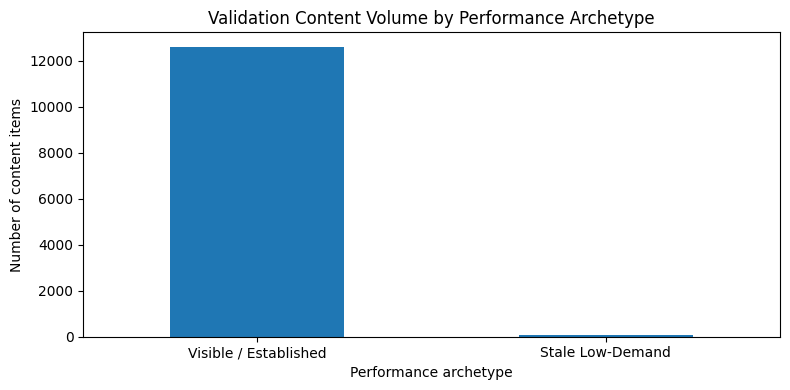

In [ ]:
archetype_counts = (
    valid_clustered["archetype"]
    .value_counts()
)

plt.figure(figsize=(8, 4))

archetype_counts.plot(
    kind="bar"
)

plt.title(
    "Validation Content Volume by Performance Archetype"
)

plt.xlabel(
    "Performance archetype"
)

plt.ylabel(
    "Number of content items"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

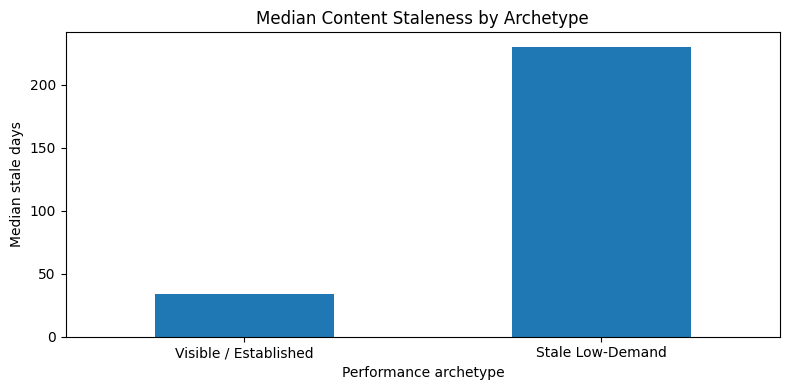

In [ ]:
plot_profile = valid_profile.copy()

plot_profile["archetype"] = (
    plot_profile.index.map(
        ARCHETYPE_NAMES
    )
)

plot_profile = (
    plot_profile
    .set_index("archetype")
)

plt.figure(figsize=(8, 4))

plot_profile[
    "stale_days_median"
].plot(
    kind="bar"
)

plt.title(
    "Median Content Staleness by Archetype"
)

plt.xlabel(
    "Performance archetype"
)

plt.ylabel(
    "Median stale days"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

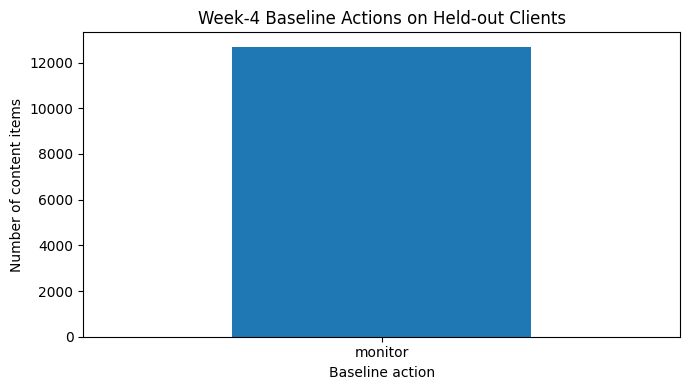

In [ ]:
action_distribution = (
    valid_comparison["baseline_action"]
    .value_counts()
)

plt.figure(figsize=(7, 4))

action_distribution.plot(
    kind="bar"
)

plt.title(
    "Week-4 Baseline Actions on Held-out Clients"
)

plt.xlabel(
    "Baseline action"
)

plt.ylabel(
    "Number of content items"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Reproducibility

The analysis is implemented in the project repository under:

`work/notebooks/`

The main supporting notebooks are:

- `w03_data_contract.ipynb`
- `w04_baseline_score.ipynb`
- `w05_model.ipynb`
- `w06_validation_audit.ipynb`
- `w07_action_playbook.ipynb`
- `capstone.ipynb`

The model uses:

- March 2026 warehouse snapshot;
- K-Means;
- `k = 2`;
- `random_state = 42`;
- `n_init = 20`;
- client-grouped validation;
- `log1p` transformation for impressions and clicks;
- standardized clustering features.

The validation split contains no overlapping clients between training and
held-out data.

## Abstract

This case study addresses a FlyRank content-operations problem: how analysts can triage a large content inventory for human review without assuming that every stale page is a good refresh candidate. Using the March 2026 FlyRank internship warehouse snapshot, we aggregate content-level observations and apply K-Means clustering to impressions, clicks, click-through rate, average search position, and content staleness. A client-grouped holdout separates 26 training clients from 7 unseen validation clients, and the selected two-cluster solution reaches a validation silhouette of 0.6875. On the same held-out rows, K-Means surfaces 81 of 12,688 items (0.64%) as a stale/low-demand archetype, whereas the stricter stale-and-visible baseline surfaces none for refresh. The result is a descriptive decision-support framework for prioritizing human review in the FlyRank content problem—not evidence of causal refresh impact, semantic content type, or business value.



## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] Claims use careful words: observed, measured, directional, decision-support
- [ ] The same held-out validation rows are used for the model/baseline operational comparison
- [ ] No predictive metric is reported for the unsupervised task without a ground-truth label
- [ ] Committed to the repo under `work/notebooks/`


## 5-minute demo outline

**0:00–0:45 — Question and FlyRank problem**  
Ask: *What performance archetypes exist across the content inventory?* Connect it to the practical content-operations problem: with a large inventory, analysts need a defensible way to decide where human review should begin, while avoiding the assumption that staleness automatically means “refresh.”

**0:45–2:00 — Method**  
Explain the March 2026 snapshot, the five structured features (impressions, clicks, CTR, average position, and stale days), `log1p` on impressions/clicks, training-only standardization, and K-Means with a client-grouped holdout so seven unseen clients test transfer.

**2:00–3:00 — One chart**  
Show the **model-vs-baseline coverage** chart: on the same 12,688 held-out rows, K-Means surfaces 81 Stale Low-Demand items while the strict baseline surfaces 0 refresh items. Briefly explain that this is an operational coverage comparison, not model accuracy.

**3:00–4:00 — One honest result**  
The selected two-cluster model has a validation silhouette of **0.6875**, and the Stale Low-Demand archetype contains **81 / 12,688 (0.64%)** validation items. The important caveat: the clustering is descriptive and there is no ground-truth outcome label, so this does not prove which pages will benefit from a refresh.

**4:00–5:00 — Recommendation**  
Recommend starting with human review of stale pages that still have meaningful observed visibility, while diagnosing very stale/low-demand pages before investing heavily. Close by emphasizing that the output is a prioritization aid, not an automated production action.


## Shareable cuts

### Short social post

I built an unsupervised content-performance clustering workflow for a FlyRank case study: instead of treating “stale” as an automatic refresh signal, I grouped content using March 2026 search impressions, clicks, CTR, average position, and freshness. With client-grouped validation, the selected two-cluster solution reached a 0.6875 validation silhouette and surfaced 81 of 12,688 held-out items as a Stale Low-Demand archetype, while the stricter stale-and-visible baseline surfaced none. The takeaway is a small, interpretable human-review queue—not a claim that clustering predicts refresh wins or causes traffic recovery.

### Employer-facing 3-sentence summary

I built an interpretable K-Means clustering workflow to help analysts triage a large content inventory for human review, using structured search-performance and freshness signals from the March 2026 FlyRank internship warehouse snapshot. The analysis covered 27,886 content observations across 33 clients and used a client-grouped holdout, with 26 clients for training and 7 unseen clients for validation. It found two recurring performance archetypes and surfaced 81 of 12,688 held-out items as Stale Low-Demand, providing a descriptive prioritization lens while explicitly avoiding causal or business-value claims.
